# 11 Image segmentation

## Computer vision tasks

In [19]:
import os
import sys
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic

os.environ["KERAS_BACKEND"] = "jax"

import keras

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

Three main tasks:

- *Image classification*: assign one or more labels to an images;
- *Image segmentation*: partition image into different areas (locating categories of bojects), operates on **pixels**;
- *Object detection*: draw rectangles around object, and associate each object with a class.

<!-- ![Chollet three tasks](images/chollet/figure11.1.png) -->
![Chollet three tasks](https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/06/images/chollet/figure11.1.png)

<small>[DLWP](https://deeplearningwithpython.io/chapters/chapter11_image-segmentation/#computer-vision-tasks), Chapter 11, figure 11.1</small>

There are of course more: image similarity scoring (estimating how visually similar two images are), keypoint detection (pinpointing attributes of interest in an image, such as facial features), pose estimation, 3D mesh estimation, depth estimation, and so on, but almost all of them boil down the main three.

### Types of image segmentation

Image segmentation with deep learning is about using a model to assign a class to each pixel in an image, thus segmenting the image into different zones (such as “background” and “foreground” or “road,” “car,” and “sidewalk”).

- *Semantic segmentation*:  each pixel is independently classified into a semantic category, like “cat.” (Two cats belong to the same category).
- *Instance segmentation*: parses out individual object instances. (Two cats are labelled `cat 1` and `cat 2`.)
- *Panoptic segmentation*, which combines the two previous approaches, giving both a semantic label and and an instance label.

<!-- ![Chollet, Semantic segmentation vs. instance segmentation](images/chollet/figure11.2.png) -->
![Chollet, Semantic segmentation vs. instance segmentation](https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/06/images/chollet/figure11.2.png)

<small>[DLWP](https://deeplearningwithpython.io/chapters/chapter11_image-segmentation/#types-of-image-segmentation), Chapter 11, figure 11.2</small>

## Training a segmentation model from scratch

We’ll work with the [Oxford-IIIT Pets dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) – 7,390 pictures, together with *foreground-background masks for each picture*. The masks acts like labels in classification, but for each pixel: it is therefore the same size of the image (width, height, 1 (channel)).

We have three (pixel) classes:

- 1 (foreground)
- 2 (background)
- 3 (contour)

### Loading the data

In [22]:
MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

REPO_DIR = pathlib.Path("oxford-pets")
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/ml4py/dataset-iiit-pet oxford-pets/dataset-iiit-pet

In [25]:
BATCH_SIZE = 64
# We resize everything to 200 x 200 for this example.
IMG_SIZE = (200, 200)

BASE_DIR = REPO_DIR / "dataset-iiit-pet"
INPUT_DIR = BASE_DIR / "images/"
TARGET_DIR = BASE_DIR / "annotations/trimaps/"

INPUT_IMG_PATHS = sorted(INPUT_DIR.glob("*.jpg"))
TARGET_PATHS = sorted(TARGET_DIR.glob("[!.]*.png"))

image shape: (500, 448)


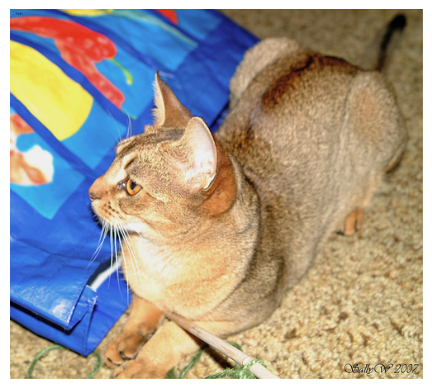

In [26]:
plt.axis("off")
img = keras.utils.load_img(INPUT_IMG_PATHS[9])
plt.imshow(keras.utils.load_img(INPUT_IMG_PATHS[9]))
print(f"image shape: {img.size}")

array shape: (448, 500, 1)
values: [  0 127 254]


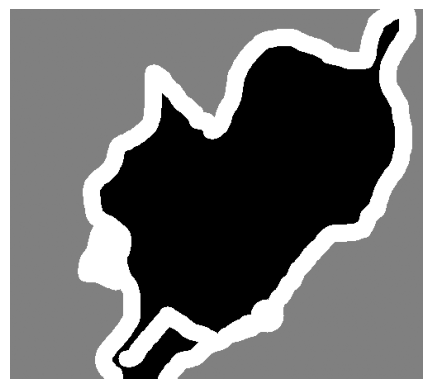

In [27]:
def display_target(target_array):
    # The original labels are 1, 2, and 3. We subtract 1 so that the
    # labels range from 0 to 2, and then we multiply by 127 so that the
    # labels become 0 (black), 127 (gray), 254 (near-white).    
    print(f"array shape: {target_array.shape}")
    normalized_array = (target_array.astype("uint8") - 1) * 127
    values = np.unique(normalized_array.reshape(-1,))

    # background is 127 (grey), boundary is 256 (white), object 0 (black)
    print(f"values: {values}")
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0], cmap="gray")

# "grayscale" mode yields a (W, H, 1) image – without it it would be (W, H, 3)
img = keras.utils.img_to_array(
    keras.utils.load_img(TARGET_PATHS[9], color_mode="grayscale")
)
display_target(img)

In [28]:
# Total number of samples in the data
num_imgs = len(INPUT_IMG_PATHS)

# Shuffles the file paths (they were originally sorted by breed). We
# use the same seed (1337) in both statements to ensure that the input
# paths and target paths stay in the same order.
random.Random(1337).shuffle(INPUT_IMG_PATHS)
random.Random(1337).shuffle(TARGET_PATHS)

def path_to_input_image(path):
    return keras.utils.img_to_array(keras.utils.load_img(path, target_size=IMG_SIZE))

def path_to_target(path):
    img = keras.utils.img_to_array(
        keras.utils.load_img(path, target_size=IMG_SIZE, color_mode="grayscale")
    )
    # Subtracts 1 so that our labels become 0, 1, and 2
    img = img.astype("uint8") - 1
    return img

# Loads all images in the input_imgs float32 array and their masks in
# the targets uint8 array (same order). The inputs have three channels
# (RGB values), and the targets have a single channel (which contains
# integer labels).
input_imgs = np.zeros((num_imgs,) + IMG_SIZE + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + IMG_SIZE + (1,), dtype="uint8")
for i in range(num_imgs):
    input_imgs[i] = path_to_input_image(INPUT_IMG_PATHS[i])
    targets[i] = path_to_target(TARGET_PATHS[i])

In [29]:
# Reserves 1,000 samples for validation
num_val_samples = 1000
# Splits the data into a training and a validation set
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]
val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

### Baseline

#### Entropy of the dataset

This is a classification task, with each pixel classified into three categories. In that sense, we can start our baseline by considering each pixel individually, and looking at the probability of each class. Is our dataset balanced or not?

In [195]:
counts = np.bincount(val_targets.ravel())
probs = counts / counts.sum()
counts, probs

(array([11987180, 23356366,  4656454]),
 array([0.2996795 , 0.58390915, 0.11641135]))

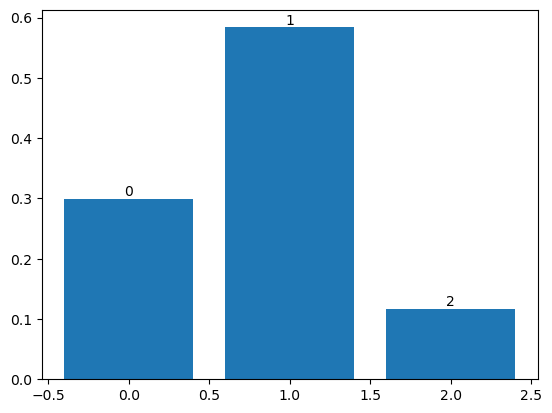

In [33]:
bars = plt.bar(range(len(probs)), probs)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(i), ha='center', va='bottom')

The entropy is, given a random variable $\mathcal {X} $:

$$\mathrm {H} (X):= -\sum _{ x\in {\mathcal {X} } } p(x) \log p(x) $$

This is the loss we would get if we used the best static (no context) predictor: always outputting the class probabilities present in our dataset (we would want a lower loss than that).

In [141]:
# a small epsilon for numeric stability
nll = - np.sum(probs * np.log(probs + 1e-12))
print(f"Baseline loss <> Entropy of the dataset: {nll.item()}.")

Baseline loss <> Entropy of the dataset: 0.9256323720884551.


##### Note: not the accuracy!

Note that this is a baseline for the **loss** (negative log likelihood for a multi-class classification problem), not the accuracy (which we won't be measuring here). If we were interested in the accuracy, we would do the expected $p_{\text{most frequent class}$:

In [146]:
print(f"Baseline accuracy predicting the most frequent class: {np.max(probs)} ({np.max(probs) * 100}%).")

Baseline accuracy predicting the most frequent class: 0.58390915 (58.390915%).


#### Metric: Intersection over Union (IoU)

[IoU class documentation](https://keras.io/api/metrics/segmentation_metrics/#iou-class)

To evaluate the model, we’ll use a metric named **Intersection over Union (IoU)**. It’s a measure of the match between the ground truth segmentation masks and the predicted masks. It can be computed separately for each class or averaged over multiple classes. Here’s how it works:

- Compute the **intersection** between the masks, the area where the prediction and ground truth overlap.
- Compute the **union** of the masks, the total area covered by both masks combined. This is the whole space we’re interested in — the target object and any extra bits your model might have included by mistake.
- **Divide the intersection area by the union area** to get the IoU. It’s a number between 0 and 1, where 1 denotes a perfect match, and 0 denotes a complete miss.

<!-- ![Diagram showing Intersection over Union: if large overlap, close to one; if separate, close to zero](images/IoU.png) -->

![Diagram showing Intersection over Union: if large overlap, close to one; if separate, close to zero](https://raw.githubusercontent.com/jchwenger/DLWP/refs/heads/main/lectures/06/images/IoU.png)

Source: [Terven & Cordova-Esparza, "A Comprehensive Review of YOLO Architectures in Computer Vision: From YOLOv1 to YOLOv8 and YOLO-NAS"](https://arxiv.org/abs/2304.00501)

In practice, this can be computed using the confusion matrix of the predictions:

```python
iou = true_positives / (true_positives + false_positives + false_negatives)
```

See also [Andrew Ng's explanation](https://www.youtube.com/watch?v=ANIzQ5G-XPE&list=PLkDaE6sCZn6Gl29AoE31iwdVwSG-KnDzF&index=27) (and further videos).

In [ ]:
iou_test = keras.metrics.IoU(
    # Specifies the total number of classes
    num_classes=3,
    # Specifies the class to compute IoU for (0 = foreground)
    target_class_ids=(0,),
    # Our targets are sparse (integer class IDs).
    sparse_y_true=True,
    # Unlike during training, our predictions are sparse as well
    sparse_y_pred=True,
)

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

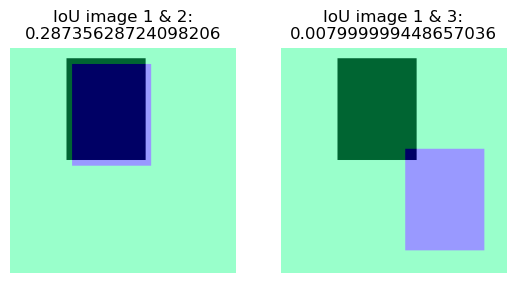

In [183]:
# create synthetic images, adding an area with zeros
test_image1 = np.ones((200,200,1)).astype("int32")
test_image1[10:100, 50:120] = 0.
    
test_image2 = np.ones((200,200,1)).astype("int32")
test_image2[15:105, 55:125] = 0.

test_image3 = np.ones((200,200,1)).astype("int32")
test_image3[90:180, 110:180] = 0.

# computing the IoU for one pair
iou_test.update_state(test_image1, test_image2)
io_img1_img2 = iou_test.result().item()

# reset
iou_test.reset_state()

# computing the IoU for the other pair
iou_test.update_state(test_image1, test_image3)
io_img1_img3 = iou_test.result().item()

fig, axs = plt.subplots(1, 2)

# ---- Image 1 vs 2 ----
axs[0].set_title(f"IoU image 1 & 2:\n{io_img1_img2}")
axs[0].imshow(test_image1, cmap="gray")
axs[0].imshow(test_image2, cmap="winter", alpha=0.4)
axs[0].axis("off")

# ---- Image 1 vs 3 ----
axs[1].set_title(f"IoU image 1 & 3:\n{io_img1_img3}")
axs[1].imshow(test_image1, cmap="gray")
axs[1].imshow(test_image3, cmap="winter", alpha=0.4)
axs[1].axis("off")

What do we get if we make a 'trivial' prediction: all our prediction images would just be contour only (zeros)?

Zero-only prediction IoU: 0.2996794581413269.


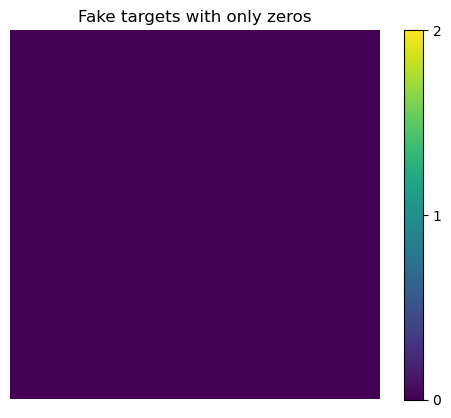

In [194]:
# dtype to remove annoying warning
val_targets_all_zeros = np.zeros_like(val_targets, dtype="int32")

iou_test.reset_state()

iou_test.update_state(val_targets.astype("int32"), val_targets_all_zeros)
print(f"Zero-only prediction IoU: {iou_test.result().item()}.", )

plt.imshow(val_targets_all_zeros[0], cmap="viridis", vmin=0, vmax=2)
plt.colorbar(ticks=[0, 1, 2])
plt.title("Fake targets with only zeros")
_ = plt.axis("off")

Center-zero prediction IoU: 0.44744959473609924.


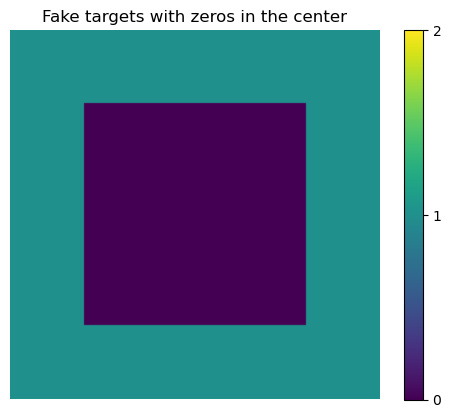

In [193]:
# dtype to remove annoying warning
val_targets_half_zeros = np.ones_like(val_targets, dtype="int32")

# changing the margin will affect the result! 5 seems to be a sweet spot...
offset_height = val_targets_half_zeros.shape[1] // 5
offset_width = val_targets_half_zeros.shape[2] // 5
val_targets_half_zeros[:, offset_height: -offset_height, offset_width: -offset_width] = 0.

iou_test.reset_state()

iou_test.update_state(val_targets.astype("int32"), val_targets_half_zeros)
print(f"Center-zero prediction IoU: {iou_test.result().item()}.", )
 
plt.imshow(val_targets_half_zeros[0], cmap="viridis", vmin=0, vmax=2)
plt.colorbar(ticks=[0, 1, 2])
plt.title("Fake targets with zeros in the center")
_ = plt.axis("off")

### Building and training the segmentation model

In [28]:
def get_model(IMG_SIZE, num_classes, tf_dataset=True):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    # Don't forget to rescale input images to the [0–1] range.    
    x = keras.layers.Rescaling(1./255)(inputs)
    
    # We use padding="same" everywhere to avoid the influence of border
    # padding on feature map size.
    # shrink input (like an encoder) – using strides instead of max pooling!
    x = keras.layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
    x = keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
    x = keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(256, 3, activation="relu", padding="same")(x)

    # unshrink input (like a decoder)
    x = keras.layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(256, 3, activation="relu", padding="same", strides=2)(x)
    x = keras.layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(128, 3, activation="relu", padding="same", strides=2)(x)
    x = keras.layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = keras.layers.Conv2DTranspose(64, 3, activation="relu", padding="same", strides=2)(x)
    
    # We end the model with a per-pixel three-way softmax to classify
    # each output pixel into one of our three categories.
    outputs = keras.layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

    model = keras.Model(inputs, outputs)
    return model

model = get_model(IMG_SIZE=IMG_SIZE, num_classes=3)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 25, 25, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 50, 50, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 50, 50, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 100, 100, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 100, 100, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 200, 200, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 200, 200, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,880,643 (10.99 MB)

 Trainable params: 2,880,643 (10.99 MB)

 Non-trainable params: 0 (0.00 B)

#### Strided Convolutions (instead of MaxPooling)

One important difference between the first half of this model and the classification models you’ve seen before is the way we do **downsampling**: in our former classification model, we used `MaxPooling2D` layers for downsampling. Here, we downsample by adding **strides** to every other convolution layer.

We do this because, in the case of *image segmentation*, we care a lot about the **spatial location of information** in the image since we need to produce **per-pixel target masks** as output of the model.

When you do 2 × 2 max pooling, you are completely destroying location information within each pooling window: you return one scalar value per window, with zero knowledge of which of the four locations in the windows the value came from.

So, while `MaxPooling2D` layers perform well for classification tasks, they would work less well for a segmentation task. Strided convolutions can downsample while retaining location information. 

#### Transposed Convolutions

This is similar to the previous ConvNet we've seen.

One important difference between the first half of this model and the classification models you’ve seen before is the way we do downsampling: in the classification ConvNets from chapter 8, we used `MaxPooling2D` layers to downsample feature maps. Here, we downsample by adding strides to every other convolution layer. We do this because, in the case of image segmentation, we care a lot about the **spatial location of information** in the image since we need to produce per-pixel target masks as output of the model. (When you do 2 × 2 max pooling, you are completely destroying location information within each pooling window.) Strided convolutions do a better job at downsampling feature maps while retaining location information. (Note that we tend to use strides instead of max pooling in any model that cares about feature location, e.g. in chapter 17.)

The second half of the model is a stack of `Conv2DTranspose` layers. What are those? Well, the output of the first half of the model is a feature map of shape `(25, 25, 256)`, but we want our final output to predict a class for each pixel, matching the original spatial dimensions. The final model output will have shape `(200, 200, num_classes)`. Therefore, we need to apply a kind of **inverse** of the transformations we’ve applied so far, to **upsample** the feature maps. That’s the purpose of the Conv2DTranspose layer: you can think of it as a kind of convolution layer that learns to upsample.

| input shape | layer operation (note: same kernel/stride, flipped # filters) | output shape |
| --- | --- | --- |
|`(100, 100, 64)` | `Conv2D(128, 3, strides=2, padding="same")` | `(50, 50, 128)` |
| `(50, 50, 128)` | `Conv2DTranspose(64, 3, strides=2, padding="same")` | `(100, 100, 64)` |

So after compressing our inputs into feature maps of shape `(25, 25, 256)` via a stack of `Conv2D` layers, we can simply apply the corresponding sequence of `Conv2DTranspose` layers followed by a final `Conv2D` layer to produce outputs of shape `(200, 200, 3)`.

<!-- ![Kaveh, stack overflow](images/deconv/deconv.1.png) -->
![Kaveh, stack overflow](https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/06/images/deconv/deconv.1.png)

<small>Source: [Kaveh's answer to "In Keras what is the difference between Conv2DTranspose and Conv2D", stack overflow](https://stackoverflow.com/a/68980531)</small>

<!-- ![Kaveh, stack overflow](images/deconv/deconv.2.png) -->
![Kaveh, stack overflow](https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/06/images/deconv/deconv.2.png)


<small>Source: [Kaveh's answer to "In Keras what is the difference between Conv2DTranspose and Conv2D", stack overflow](https://stackoverflow.com/a/68980531)</small>

#### The U-Net

This encoder-decoder structure is known as the **U-Net** (more on this when we talk about diffusion), developed for medical segmentation. See [Olaf Ronneberger, Philipp Fischer, Thomas Brox, U-Net: Convolutional Networks for Biomedical Image Segmentation, arxiv](https://arxiv.org/abs/1505.04597).

### Compilation & Training

In [29]:
# ⚠️NOTE⚠️: The following IoU metric is *very* slow on the PyTorch backend!
# If you are running with PyTorch, we recommend re-running the notebook with Jax
# or TensorFlow, or skipping to the next section of this chapter.

foreground_iou = keras.metrics.IoU(
    # Specifies the total number of classes
    num_classes=3,
    # Specifies the class to compute IoU for (0 = foreground)
    target_class_ids=(0,),
    name="foreground_iou",
    # Our targets are sparse (integer class IDs).
    sparse_y_true=True,
    # But our model's predictions are a dense softmax!
    sparse_y_pred=False,
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[foreground_iou],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "oxford_segmentation.keras",
        save_best_only=True
    )
]

history = model.fit(
    train_input_imgs,
    train_targets,
    epochs=50,
    batch_size=BATCH_SIZE,
    validation_data=(val_input_imgs, val_targets),
    callbacks=callbacks,
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - foreground_iou: 0.0160 - loss: 0.9943 - val_foreground_iou: 0.4725 - val_loss: 0.7825
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - foreground_iou: 0.3801 - loss: 0.8274 - val_foreground_iou: 0.4316 - val_loss: 0.8019
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - foreground_iou: 0.4477 - loss: 0.7874 - val_foreground_iou: 0.4911 - val_loss: 0.7192
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - foreground_iou: 0.4924 - loss: 0.6964 - val_foreground_iou: 0.5148 - val_loss: 0.6545
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - foreground_iou: 0.5283 - loss: 0.6135 - val_foreground_iou: 0.5745 - val_loss: 0.5536
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - foreground_iou: 0.5845 - loss: 0.5538 - val_foreground_iou: 0.6256 - val_loss: 0.4950
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - foreground_iou: 0.6062 - loss: 0.5197 - val_foreground_iou: 0.5961 - val_loss: 0.5170
Epoch 8/50

### Plotting & results

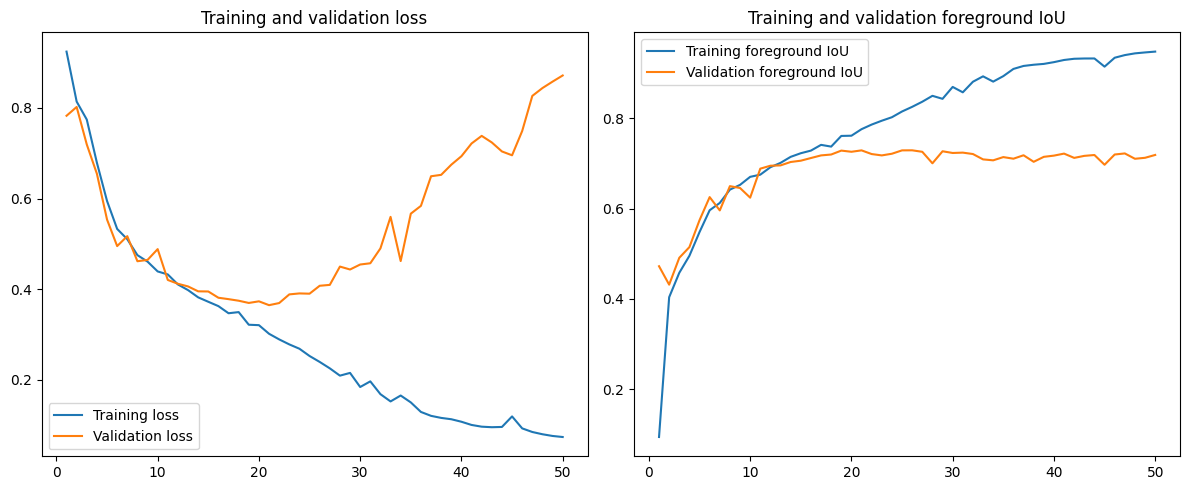

In [33]:
epochs = range(1, len(history.history["loss"]) + 1)

loss = history.history["loss"]
val_loss = history.history["val_loss"]

iou_metric = history.history["foreground_iou"]
val_iou_metric = history.history["val_foreground_iou"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left subplot: loss
ax1.plot(epochs, loss, label="Training loss")
ax1.plot(epochs, val_loss, label="Validation loss")
ax1.set_title("Training and validation loss")
ax1.legend()

# Right subplot: foreground IoU
ax2.plot(epochs, iou_metric, label="Training foreground IoU")
ax2.plot(epochs, val_iou_metric, label="Validation foreground IoU")
ax2.set_title("Training and validation foreground IoU")
ax2.legend()

plt.tight_layout()
plt.show()


Big overfitting here! The task now would be to reduce that, and see if it's possible to push the validation IoU upwards.

Quick note. Below you can see the best values during training:

In [56]:
print(f"Min val loss during training: {np.min(history.history['val_loss'])} at epoch {np.argmin(history.history['val_loss'])}")
print(f"Max val IoU during training: {np.max(history.history['val_foreground_iou'])} at epoch {np.argmax(history.history['val_foreground_iou'])}")

Min val loss during training: 0.3647443950176239 at epoch 20
Max val IoU during training: 0.7292941808700562 at epoch 25


However, our model here is the one at the last training iteration, so you can see that its performance, especially the loss, is much worse (and so is the IoU, although overfitting affects that metric less).

In [ ]:
val_loss, val_iou = model.evaluate(val_input_imgs, val_targets, verbose=0)
print(f"(End-of-training model validation loss: {val_loss}, validation IoU: {val_iou}.")

Validation loss: 0.8713516592979431, validation IoU: 0.7190244793891907.


By reloading the model, we get only the 'best' one, with the peak performance seen during training.

In [53]:
reloaded_model = keras.models.load_model(MODELS_DIR / "oxford_segmentation.keras")

In [55]:
val_loss, val_iou = reloaded_model.evaluate(val_input_imgs, val_targets, verbose=0)
print(f"Reloaded (best) model validation loss: {val_loss}, validation IoU: {val_iou}.")

Reloaded (best) model validation loss: 0.36473870277404785, validation IoU: 0.7291584610939026.


### Test our trained model

In [34]:
def display_mask(model, i):

    # get image
    test_image = val_input_imgs[i]

    # get predictions, which have three values (class probabilities) for each pixel
    pred = model.predict(np.expand_dims(test_image, 0), verbose=0)[0]
    # turn probabilities into an integer mask (0,1,2)
    mask = np.argmax(pred, axis=-1)
    # -> (0, 127, 254)
    mask *= 127

    fig, (ax1,ax2) = plt.subplots(1,2)
    ax1.axis("off")
    ax1.imshow(keras.utils.array_to_img(test_image))
    ax2.axis("off")
    ax2.imshow(mask, cmap="gray")
    plt.show()

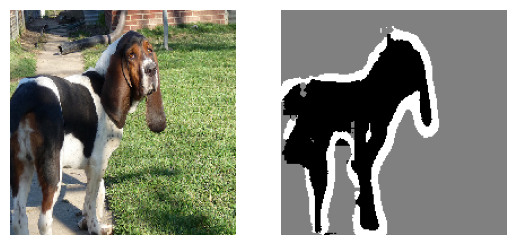

In [36]:
i = np.random.randint(0, len(val_input_imgs))
display_mask(reloaded_model, i)

### Save to Google Drive

In [61]:
EXPORT = False

if EXPORT:
    # zip models
    !zip oxford_segmentation.models.zip {MODELS_DIR}/*
    # connect to drive
    from google.colab import drive
    drive.mount('/content/drive')
    # copy zip to drive (adjust folder as needed)
    !cp oxford_segmentation.models.zip drive/MyDrive/gold/IS53024B-Artificial-Intelligence/models

## Using a pretrained segmentation model

Check out the steps [in the book](https://deeplearningwithpython.io/chapters/chapter11_image-segmentation/#using-a-pretrained-segmentation-model)!

### See also

[Keras tutorial on Segment Anything](https://keras.io/keras_hub/guides/segment_anything_in_keras_hub/)  
["Automatically generating object masks with SAM" notebook (Keras)](https://github.com/tirthasheshpatel/segment_anything_keras/blob/main/Segment_Anything_Automatic_Mask_Generator_Demo.ipynb)  
[Facebook Research's "Segment Anything"](https://github.com/facebookresearch/segment-anything) and ["Segment Anything 2"](https://github.com/facebookresearch/sam2) GitHub repositories